# Trajectory Algorithm Project

In [63]:
import numpy as np

# Random seed
rng = np.random.default_rng(42)

For this preliminary work, we consider a case in which the trajectories under study are linear and have a constant velocity.

$$
\dot{x} = v_x ~~~~ \text{and} ~~~~ \dot{v}_x = 0
$$

The state vector is $[x, y, v_x, v_y]$ is in 2D Cartesian coordinates, but real radar measurements are in polar coordinates.

In [64]:
# matrix of the constant velocity model and linear trajectory
def F_cv(dt):
    return np.array([
        [1, 0, dt, 0], # x
        [0, 1, 0, dt], # y
        [0, 0, 1, 0],  # v_x
        [0, 0, 0, 1],  # v_y
    ])

Addition a Discrete White Noise Acceleration (DWNA). 
We assume that a white random acceleration `q` (continuous white noise) disturbs the target between two time step `dt`, and we analytically integrate its effect on position and velocity. Hence the terms $\mathrm{d}t^3/3$ (variance of position, since the double integral of the noise accumulates over $\mathrm{d}t^3$) and $\mathrm{d}t^2/2$ (cross-covariance between position and velocity).

$$
\text{We got} ~~~~ \dot{x} = v_x  ~~~~ \text{and} ~~~~ \dot{v}_x = w(t)
$$
where $w(t)$ is a white noise with an intensity $q$ (spectral power density).

Over the interval between 2 time steps $[0, dt]$, the process error added to the true state (relative to the ideal “constant velocity” model) is:

$$
\delta v_x ​= \int_0^{\mathrm{d}t} ​w(s) \mathrm{d}s 
\implies 
\delta x = \int_0^{\mathrm{d}t} \delta v_x​(s) \mathrm{d}s 
= \int_0^{\mathrm{d}t} \int_0^s ​w(\tau) \mathrm{d}\tau \mathrm{d}s
$$

In other words: the same white noise signal $w(t)$ is integrated once to obtain the velocity error, and twice to obtain the position error !

We will use:
- `q13`: The variance of the accumulated position error resulting from the double integration of the unknown random acceleration over the interval $\mathrm{d}t$.
- `q12`: The cross-covariance. It exists because the position error and the velocity error for this time step are calculated from the same random acceleration, and are therefore statistically related: an unexpected positive acceleration simultaneously increases both the final velocity and the final position.
- `dt`: Variance of the velocity error = simple integral of white noise.A linear growth with respect to dt.

In [65]:
# process noise covariance matrix for the constant velocity model
def Q_cv(dt, q):
    
    # discrete white noise acceleration model
    q13 = (dt**3) / 3
    q12 = (dt**2) / 2

    Q = q * np.array([
        [q13, 0, q12, 0], # variance on x from the accumulated position error (q13) and the cross terms position-velocity (q12)
        [0, q13, 0, q12], # variance on y from the accumulated position error (q13) and the cross terms position-velocity (q12)
        [q12, 0, dt, 0],  # variance on v_x from the cross terms position-velocity (q12) and the acceleration noise (dt)
        [0, q12, 0, dt]   # variance on v_y from the cross terms position-velocity (q12) and the acceleration noise (dt)
        ])
    
    return Q

This allows continuous process uncertainty to be propagated into a discrete system. The parameter $q$ (noise intensity) is the only control that tells the filter that “the target may deviate from the linear model.”
It is this parameter that allows the filter to “follow” the turns without having explicitly modeled them.

In [66]:
def simulate_true_trajectory(dt, N, turn_schedule):
    """
    dt: time step (s)
    N: number of time steps
    turn_schedule: list of (start_step, end_step, omega) turn rate segments (rad/s).
    """
    # Add a verification to ensure that the turn_schedule is valid
    for (s0, s1, om) in turn_schedule:
        if s0 < 0 or s1 > N or s0 >= s1:
            raise ValueError(f"Invalid turn schedule: ({s0}, {s1}, {om})")

    # Initialize the state vector: [x, y, vx, vy]
    state = np.array([0.0, 0.0, 200.0, 0.0])  # (m, m, m/s, m/s)

    # states will hold the trajectory of the object over time
    # we fill it with the initial state and then update it in the loop
    states = [state.copy()]

    # Loop over time steps to simulate the trajectory
    for k in range(1, N):

        t = k * dt  # current time (s)

        # Omega = 0 => straight line motion
        # Omega != 0 => turning motion
        omega = 0.0
        # for every scheduled turn segment
        for (s0, s1, om) in turn_schedule:
            # if we are within a scheduled turn segment
            if s0 <= t < s1:
                # update the turn rate
                omega = om
                break
        
        # Update the state based on the current turn rate
        x, y, vx, vy = state
        # if the turn rate is very small, we can approximate the motion as straight line
        if abs(omega) < 1e-8:
            x += vx * dt
            y += vy * dt
        # otherwise, we need to account for the turning motion
        else:
            # scalar speed and heading
            speed = np.hypot(vx, vy)
            heading = np.arctan2(vy, vx) + omega * dt

            # update the velocity components based on the new heading
            vx = speed * np.cos(heading)
            vy = speed * np.sin(heading)

            x += vx * dt
            y += vy * dt
        
        # Add the updated state to the list of states
        state = np.array([x, y, vx, vy])
        states.append(state.copy())

    return np.array(states)

The heading is updated before the position is advanced, and the position uses the speed after the turn rather than the average speed over the interval. This is a semi-implicit Euler-type scheme (similar to the “symplectic Euler” method) applied to circular motion; it is not the exact solution for an arc of a circle.

For a turn at a constant rate $\omega$, the exact (closed-form) solution for the displacement over $dt$ is known analytically (as used in the classical [Bar-SHalom's CT model](https://www.researchgate.net/profile/Yaakov-Bar-Shalom-2/publication/3002842_Interacting_multiple_model_methods_in_target_tracking_A_survey/links/5b367aeda6fdcc8506df9f47/Interacting-multiple-model-methods-in-target-tracking-A-survey.pdf}) ) 
and involves $\frac{\sin⁡(\omega \mathrm{d}t)}{\omega}$ and $\frac{1 - \cos⁡( \omega \mathrm{d}t)}{\omega}$ rather than a simple $v_x*\mathrm{d}t$. 
The scheme used here therefore introduces an integration error of order $ O (\mathrm{d}t)$ (or even $ O(\mathrm{d}t^2)$ depending on the exact formulation) in position at each turn step, negligible here since $\mathrm{d}t = 1s$ and $\omega$ remains small ($\thicksim 3 ~\text{or}~ 4°/s$, i.e., a rotation of a few degrees per step), but this would no longer be negligible with a larger $\mathrm{d}t$ or a more rapid rate of turn (a missile, for example).

Indeed, the turn procedure assumes a constant speed and a heading that turns at a constant rate:

$$
\theta(t) = \theta_0 + \omega t 
~~~,~~~
v_x(t) = V \cos\theta(t)
~~~,~~~
v_y(t) = V \sin⁡\theta(t)
$$

The exact position is obtained by performing an analytical integration:

$$
x(t) 
= 
x_0 + V \int_0^t \cos⁡(\theta_0 + \omega s) \mathrm{d}s
=
x_0 + \frac{V}{\omega}[\sin⁡(\theta_0 + \omega t) − \sin⁡\theta_0]
$$

By rewriting $V \cos\theta_0 = v_{x0}$ and $V \sin \theta_0 = v_{y0}$ (the cartesian speeds at the beginning of the time step) and $ \sin⁡(\theta_0 + \omega \mathrm{d}t)$ with the addtion formula, we get:

$$
\Delta x = \frac{\sin( \omega \mathrm{d}t)}{\omega} ​v_{x0} ​− \frac{1 - \cos(\omega \mathrm{d}t)}{\omega} v_{y0} 
\\
{}
\\
\Delta y = \frac{1 - \cos( \omega \mathrm{d}t)}{\omega} ​v_{x0} + \frac{\sin(\omega \mathrm{d}t)}{\omega} v_{y0}
$$

## Addition of a radar measurment function

In [67]:
def radar_measurements(states, sigma_r, sigma_theta, radar_pos):
    """
    states: array of shape (N, 4) containing the true states [x, y, vx, vy]
    sigma_r: standard deviation of range measurement noise (m)
    sigma_theta: standard deviation of bearing measurement noise (rad)
    radar_pos: position of the radar (x, y) in meters
    """
    rx, ry = radar_pos
    meas = []
    # for each state
    for s in states:
        # s[0] = x, s[1] = y
        # dx = x-rx and dy = y-ry represents the relative position of the target with respect to the radar
        dx, dy = s[0] - rx, s[1] - ry

        # compute the range
        r = np.hypot(dx, dy)
        # addition of Gaussian noise to the range
        r += rng.normal(0, sigma_r)

        # compute the bearing
        theta = np.arctan2(dy, dx)
        # addition of Gaussian noise to the bearing
        theta += rng.normal(0, sigma_theta)
        
        meas.append([r, theta])
    return np.array(meas)

In [68]:
np.radians(3)

np.float64(0.05235987755982989)

In [69]:
# time step
dt = 1.0
# number of time steps
N = 150

# Define the turn schedule as a list of tuples (start_time, end_time, turn_rate)
# Here 2 turn segments are defined
turn_schedule = [( 40,   70,    np.radians(3)), # 3°/s turn from t=40s to t=70s
                 (100,  130,   -np.radians(4)), # -4°/s turn from t=100s to t=130s
                 ]

# Simulate the true trajectory and generate radar measurements
states = simulate_true_trajectory(dt, N, turn_schedule)

radar_pos = (5000.0, 5000.0)
meas = radar_measurements(states, sigma_r=50.0, sigma_theta=np.radians(0.5), radar_pos=radar_pos)

print(states.shape, meas.shape, "\n")
print("True states:\n", states[:3], "\n")
print("Radar measurements:\n", meas[:3])

(150, 4) (150, 2) 

True states:
 [[  0.   0. 200.   0.]
 [200.   0. 200.   0.]
 [400.   0. 200.   0.]] 

Radar measurements:
 [[ 7.08630367e+03 -2.36527006e+00]
 [ 6.96861194e+03 -2.32758118e+00]
 [ 6.69656334e+03 -2.32591557e+00]]


In [70]:
import numpy as np
import matplotlib.pyplot as plt


def plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule):
    """
    Plots the true trajectory and the radar measurements.
    
    states: array of shape (N, 4) containing the true states [x, y, vx, vy]
    meas: array of shape (N, 2) containing the radar measurements [r, theta]
    radar_pos: position of the radar (x, y) in meters
    turn_schedule: list of (start_step, end_step, omega) turn rate segments (rad/s).
    """
    
    # The mesurements are polar (r, theta) -> we convert them to cartesian
    # only for visualization purposes, to display them on the same frame as the true trajectory.
    # ATTENTION : this is only a geometric conversion for plotting, not what the filter actually does (which works directly in (r, theta)).
    meas_x = radar_pos[0] + meas[:, 0] * np.cos(meas[:, 1])
    meas_y = radar_pos[1] + meas[:, 0] * np.sin(meas[:, 1])

    fig, ax = plt.subplots(figsize=(9, 7))

    # True trajectory
    ax.plot(states[:, 0], states[:, 1], color="tab:blue", lw=2, label="True trajectory")
    ax.scatter(states[0, 0], states[0, 1], color="tab:blue", marker="o", s=60, zorder=5, label="Target start")

    # Turn segments : we highlight them on the true trajectory
    for (s0, s1, om) in turn_schedule:
        ax.plot(states[s0:s1, 0], states[s0:s1, 1], color="orange", lw=3,
                label="Turn" if (s0, s1, om) == turn_schedule[0] else None)

    # radar measurements (noisy, reconverted to cartesian)
    ax.scatter(meas_x, meas_y, color="tab:red", s=12, alpha=0.7, label="Radar measurements (noisy)")

    # Position of the radar
    ax.scatter(*radar_pos, color="black", marker="^", s=140, label="Radar")

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("True trajectory and noisy radar measurements")
    ax.legend(loc="best")
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

    plt.tight_layout()

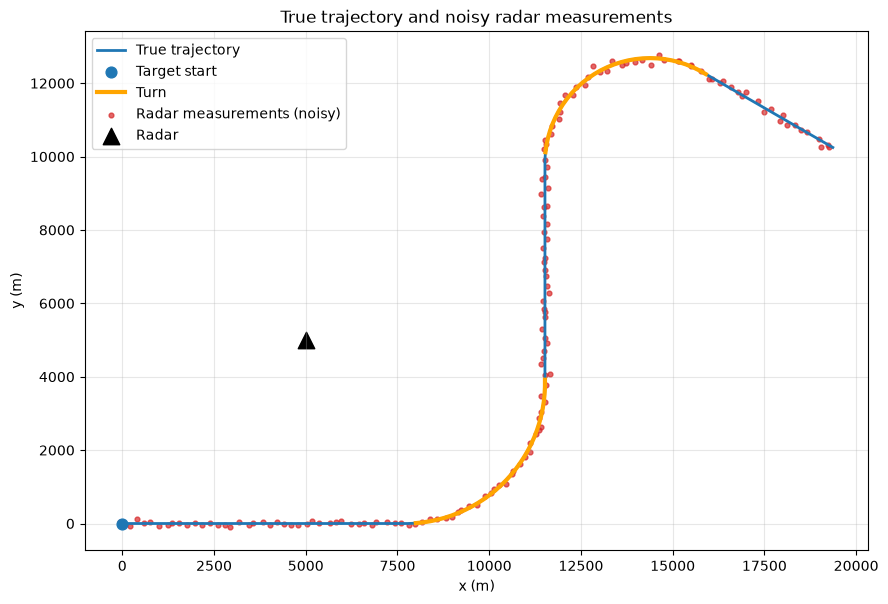

In [71]:
plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule)

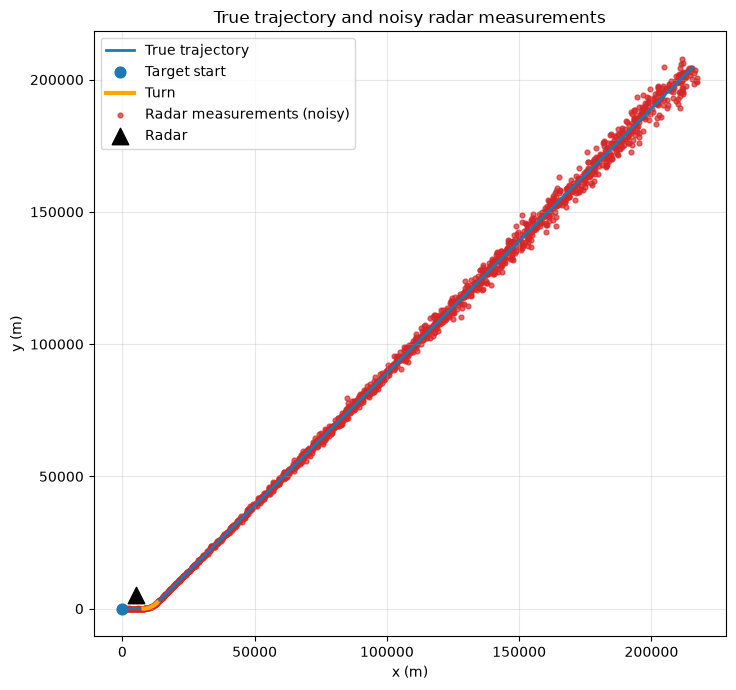

In [79]:
# time step
dt = 1.0
# number of time steps
N = 1500

turn_schedule = [( 40,   70,    np.radians(1.5))]

# Simulate the true trajectory and generate radar measurements
states = simulate_true_trajectory(dt, N, turn_schedule)

radar_pos = (5000.0, 5000.0)
meas = radar_measurements(states, sigma_r=50.0, sigma_theta=np.radians(0.5), radar_pos=radar_pos)

plot_trajectory_and_measurements(states, meas, radar_pos, turn_schedule)